# SimSiam-UNet
Self-supervised pretraining of the U-Net encoder using SimSiam, followed by supervised fine-tuning for segmentation across multiple label fractions.

**Pipeline:**
1. Pretrain the U-Net encoder with SimSiam (no labels needed)
2. Attach the decoder and fine-tune for segmentation at each label fraction (5%, 10%, 20%, 50%)

## Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

TRAIN_PATH   = "datasets/KDSB/train/"
TEST_PATH    = "datasets/KDSB/test/"
SAVE_DIR     = "saved_models"                        # where .npy and .keras files are saved
SAVE_NP = "saved_np"
DATASET_NAME = "KDSB"                     # used in .npy filenames

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to train segmentation at
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]

val_split    = 0.3
THRESHOLD    = 0.5

# SimSiam pretraining
PRETRAIN_EPOCHS    = 100
PRETRAIN_BATCH     = 8
PROJECT_DIM        = IMG_HEIGHT // 2      # projection head dimension
PREDICTOR_DIM      = 64                   # predictor MLP hidden dim
WEIGHT_DECAY       = 5e-4
PRETRAIN_FLG       = True                 # False = load saved weights
PRETRAINED_WEIGHTS = "simsiam_encoder.keras"

# Segmentation fine-tuning
FINETUNE_EPOCHS    = 200
FINETUNE_BATCH     = 8
TRAIN_FLG          = True                 # False = skip fine-tuning

## Imports

In [5]:
import os
import random
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import *
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy
from hausdorff import hausdorff_distance

## Data Loading

In [6]:
x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

print(x_train_path)

if all(os.path.exists(p) for p in [x_train_path, y_train_path, x_test_path, y_test_path]):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")
    train_ids = next(os.walk(TRAIN_PATH + 'org/'))[2][:]
    test_ids  = next(os.walk(TEST_PATH  + 'org/'))[2][:]
    print(f"Train images: {len(train_ids)}, Test images: {len(test_ids)}")

    X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)
    X_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
        img = imread(TRAIN_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_train[n] = img
        mask = imread(TRAIN_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_train[n][mask[:, :, 0] / 255 > 0.] = 1.

    for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
        img = imread(TEST_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_test[n] = img
        mask = imread(TEST_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_test[n][mask[:, :, 0] / 255 > 0.] = 1.

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)
    print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")

saved_np\KDSB_X_train_256x256.npy
Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to BT-UNet and UNet notebooks.

In [7]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis)(shortcut)
    return add([shortcut, conv])

def encoder(inputs):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for f in num_filters:
        a = double_conv_layer(x, 3, f, 0.1, True)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2))(a)
    return x, skip_connections

def bottleneck(inputs):
    return double_conv_layer(inputs, 3, 256, 0.1, True)

def decoder(inputs, skip_connections):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last")(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1)
        x     = double_conv_layer(x_att, 3, f, 0.1, True)
    return x

def output(inputs):
    x = Conv2D(1, kernel_size=(1, 1))(inputs)
    x = BatchNormalization()(x)
    x = Activation('sigmoid')(x)
    return x

## SimSiam Pretraining

**How SimSiam works:**
Two augmented views of the same image pass through the shared encoder + projection MLP.
A predictor MLP is applied to one branch only. Stop-gradient on the other branch prevents collapse — no negative pairs or momentum encoder needed.

### Augmentation Pipeline

In [8]:
CROP_TO = IMG_HEIGHT
AUTO    = tf.data.AUTOTUNE
SEED    = 42

def random_resize_crop(image, scale=[0.75, 1.0], crop_size=128):
    image_shape = 96
    image = tf.image.resize(image, (image_shape, image_shape))
    size  = tf.random.uniform(shape=(1,), minval=scale[0]*image_shape,
                              maxval=scale[1]*image_shape, dtype=tf.float32)
    size  = tf.cast(size, tf.int32)[0]
    crop  = tf.image.random_crop(image, (size, size, 3))
    return tf.image.resize(crop, (crop_size, crop_size))

def flip_random_crop(image):
    image = tf.image.random_flip_left_right(image)
    return random_resize_crop(image, crop_size=CROP_TO)

def color_jitter(x, strength=0.5):
    x = tf.image.random_brightness(x, max_delta=0.8 * strength)
    x = tf.image.random_contrast(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_saturation(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_hue(x, max_delta=0.2 * strength)
    return tf.clip_by_value(x, 0, 255)

def random_apply(func, x, p):
    return func(x) if tf.random.uniform([], 0, 1) < p else x

def custom_augment(image):
    image = tf.cast(image, tf.float32)
    image = flip_random_crop(image)
    image = random_apply(lambda x: tf.image.rot90(x), image, p=0.5)
    image = random_apply(color_jitter, image, p=0.8)
    return image

ssl_ds_one = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds_two = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED + 1)   # different seed = different augmented view
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds = tf.data.Dataset.zip((ssl_ds_one, ssl_ds_two))

### LR Schedule (WarmUp + Cosine Decay)
Identical to BT-UNet notebook.

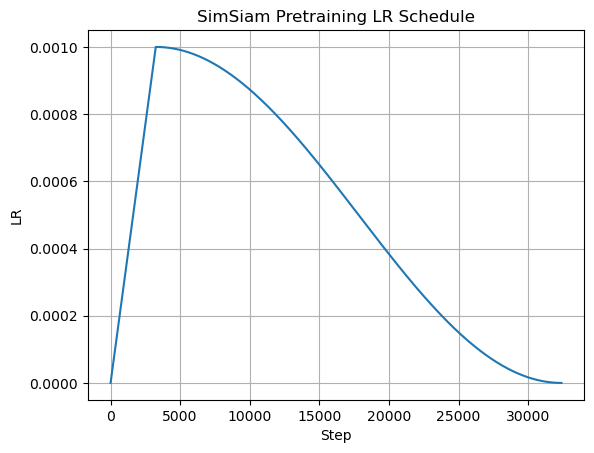

In [9]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base    = learning_rate_base
        self.total_steps           = total_steps
        self.warmup_learning_rate  = warmup_learning_rate
        self.warmup_steps          = warmup_steps
        self.pi                    = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("total_steps must be >= warmup_steps")
        lr = (0.5 * self.learning_rate_base *
              (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
                          / float(self.total_steps - self.warmup_steps))))
        if self.warmup_steps > 0:
            slope       = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr          = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)


STEPS_PER_EPOCH = len(X_train) // PRETRAIN_BATCH
TOTAL_STEPS     = STEPS_PER_EPOCH * PRETRAIN_EPOCHS
WARMUP_STEPS    = int(PRETRAIN_EPOCHS * 0.1) * STEPS_PER_EPOCH

lr_decayed_fn = WarmUpCosine(
    learning_rate_base=1e-3,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=0.0,
    warmup_steps=WARMUP_STEPS,
)

plt.plot(lr_decayed_fn(tf.range(TOTAL_STEPS, dtype=tf.float32)))
plt.title("SimSiam Pretraining LR Schedule")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid()
plt.show()

### Encoder + Projection + Predictor

In [10]:
def projection_head(x, hidden_dim=128):
    """3-layer MLP projection head (same as SimSiam paper)."""
    for i in range(2):
        x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY),
                  name=f"proj_layer_{i}")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    x = Dense(hidden_dim, name="proj_output", kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)   # BN on output, no ReLU (SimSiam paper sec 3)
    return x

def predictor_head(x, hidden_dim=64, output_dim=128):
    """2-layer MLP predictor — only applied to one branch."""
    x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY), name="pred_hidden")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dense(output_dim, name="pred_output", kernel_regularizer=l2(WEIGHT_DECAY))(x)
    return x

def build_simsiam_encoder(shape, proj_dim=128, pred_dim=64):
    inputs = Input(shape)
    s = layers.Rescaling(1.0 / 255)(inputs)
    x, skip_connections = encoder(s)
    x = bottleneck(x)
    trunk_output       = GlobalAvgPool2D()(x)
    projection_outputs = projection_head(trunk_output, hidden_dim=proj_dim)
    model = Model(inputs, projection_outputs, name="simsiam_encoder")
    return model

simsiam_enc = build_simsiam_encoder(
    (IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS),
    proj_dim=PROJECT_DIM,
    pred_dim=PREDICTOR_DIM
)
simsiam_enc.summary()

Model: "simsiam_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │         91 │ rescaling[0][0]   │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │        416 │ activation[0][0]  │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │         64 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │        688 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │      1,344 │ activation_2[0][

 Total params: 255,979 (999.92 KB)

 Trainable params: 252,235 (985.29 KB)

 Non-trainable params: 3,744 (14.62 KB)

### SimSiam Model

In [11]:
class SimSiam(tf.keras.Model):
    """
    SimSiam: Exploring Simple Siamese Representation Learning (Chen & He, 2021)

    Key idea: stop-gradient on one branch prevents representational collapse
    without needing negative pairs, large batches, or a momentum encoder.

    Loss = D(p1, z2) / 2 + D(p2, z1) / 2
    where D is negative cosine similarity and z is stop-gradiented.
    """

    def __init__(self, encoder, pred_hidden_dim=64):
        super().__init__()
        self.encoder      = encoder
        self.predictor    = self._build_predictor(encoder.output_shape[-1], pred_hidden_dim)
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def _build_predictor(self, output_dim, hidden_dim):
        inp = Input(shape=(output_dim,))
        x   = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY))(inp)
        x   = BatchNormalization()(x)
        x   = Activation("relu")(x)
        x   = Dense(output_dim, kernel_regularizer=l2(WEIGHT_DECAY))(x)
        return Model(inp, x, name="predictor")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def cosine_loss(self, p, z):
        """Negative cosine similarity. z is stop-gradiented."""
        z = tf.stop_gradient(z)
        p = tf.math.l2_normalize(p, axis=1)
        z = tf.math.l2_normalize(z, axis=1)
        return -tf.reduce_mean(tf.reduce_sum(p * z, axis=1))

    def train_step(self, data):
        view_one, view_two = data

        with tf.GradientTape() as tape:
            # Forward pass — both views through shared encoder
            z1 = self.encoder(view_one, training=True)
            z2 = self.encoder(view_two, training=True)

            # Predictor only on the online branch
            p1 = self.predictor(z1, training=True)
            p2 = self.predictor(z2, training=True)

            # Symmetric loss with stop-gradient on z
            loss = self.cosine_loss(p1, z2) / 2 + self.cosine_loss(p2, z1) / 2

        # Update encoder + predictor together
        trainable_vars = self.encoder.trainable_variables + self.predictor.trainable_variables
        gradients      = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

### Run Pretraining

Pretraining SimSiam encoder...
Epoch 1/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 121s 344ms/step - loss: 0.0019
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 115s 352ms/step - loss: -8.4175e-04
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 113s 347ms/step - loss: 0.0031
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 113s 346ms/step - loss: 9.7150e-04
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 112s 346ms/step - loss: -0.0014
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 112s 345ms/step - loss: -0.0021
Epoch 7/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 113s 346ms/step - loss: -0.0033
Epoch 8/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 112s 346ms/step - loss: -0.0060
Epoch 9/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 112s 344ms/step - loss: -0.0060
Epoch 10/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 112s 343ms/step - loss: -0.0092
Epoch 11/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 111s 342ms/step - loss: -0.0117
Epoch 12/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 111s 342ms/step - loss: -0.0128
Epoch 13/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 111s 343ms/step - loss: -0.0066
Epoch 14/10

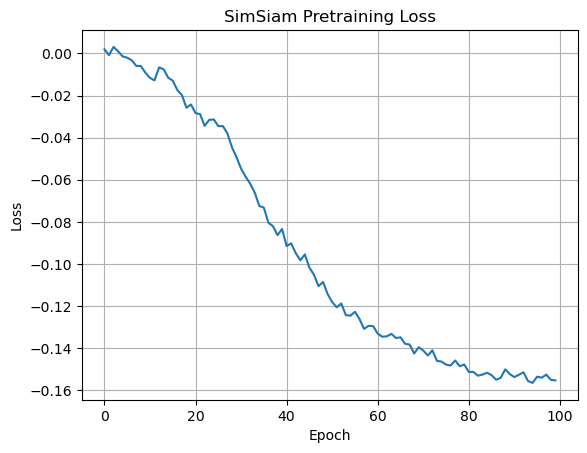

In [13]:
simsiam = SimSiam(simsiam_enc, pred_hidden_dim=PREDICTOR_DIM)
simsiam.compile(optimizer=SGD(learning_rate=lr_decayed_fn, momentum=0.9))
PRETRAIN_FLG = False

if PRETRAIN_FLG:
    print("Pretraining SimSiam encoder...")
    pretrain_history = simsiam.fit(ssl_ds, epochs=PRETRAIN_EPOCHS)
    simsiam.encoder.save(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))
    plt.plot(pretrain_history.history["loss"])
    plt.title("SimSiam Pretraining Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()
else:
    print("Loading pretrained weights...")
    simsiam.encoder.load_weights(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))

## Metrics

In [1]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth    = 1.
    y_true_f  = K.flatten(y_true)
    y_pred_f  = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)

## Loss Functions

In [2]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)

## Fine-tuning Loop — All Label Fractions
Rebuilds the full segmentation model fresh for each fraction, loading pretrained encoder weights each time.

In [3]:
all_results = []

for fraction in LABEL_FRACTIONS:

    pct      = int(fraction * 100)
    keyname  = f"SimSiam-UNET_{pct}"
    print(f"\n{'='*60}")
    print(f"Fine-tuning: {keyname}  ({pct}% labelled data)")
    print(f"{'='*60}")

    # ---- Slice the labelled subset ----
    n_labelled = int(X_train.shape[0] * fraction)
    X_subset   = X_train[:n_labelled]
    Y_subset   = Y_train[:n_labelled]

    # ---- Rebuild backbone from pretrained encoder ----
    # Strip projection head — take output of last bottleneck layer
    # (same layer indexing as BT-UNet: encoder.layers[-9].output)
    pretrained_enc = tf.keras.models.load_model(
        os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS), compile=False
    )
    backbone = tf.keras.Model(
        pretrained_enc.input,
        pretrained_enc.layers[-9].output,
        name="backbone"
    )
    backbone.trainable = True

    # Recover skip connections by name (layers 11, 22, 33, 44)
    new_skip_connections = [
        backbone.get_layer(index=11).output,
        backbone.get_layer(index=22).output,
        backbone.get_layer(index=33).output,
        backbone.get_layer(index=44).output,
    ]

    x       = decoder(backbone.output, new_skip_connections)
    outputs = output(x)
    model   = Model(backbone.input, outputs, name=keyname)

    # ---- Callbacks ----
    log_path   = "logs/"
    cur_date   = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    os.makedirs(log_path + "fit", exist_ok=True)

    callbacks = [
        ModelCheckpoint(
            os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
            monitor='val_loss', verbose=1, save_best_only=True
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10),
        EarlyStopping(monitor='val_loss', verbose=1, patience=20),
        CSVLogger(log_path + keyname + '_' + cur_date + '.log'),
        TensorBoard(log_dir=log_path + "fit/" + keyname + '_' + cur_date, histogram_freq=0),
    ]

    # ---- Compile + Train ----
    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )

    if TRAIN_FLG:
        history = model.fit(
            X_subset, Y_subset,
            validation_split=val_split,
            batch_size=FINETUNE_BATCH,
            epochs=FINETUNE_EPOCHS,
            callbacks=callbacks
        )
        plt.plot(history.history['loss'],     label='train')
        plt.plot(history.history['val_loss'], label='val')
        plt.title(f"{keyname} — Loss")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Loading saved weights...")
        model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

    # ---- Evaluate ----
    split_idx   = int(X_subset.shape[0] * (1 - val_split))
    X_tr_split  = X_subset[:split_idx]
    Y_tr_split  = Y_subset[:split_idx]
    X_val       = X_subset[split_idx:]
    Y_val       = Y_subset[split_idx:]

    preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
    preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
    preds_val   = (model.predict(X_val,      verbose=1) > THRESHOLD).astype(np.float32)
    preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

    print("\nTRAIN")
    train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
    print("\nFULL DATASET")
    full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
    print("\nVALIDATION")
    val_m   = evalResult(Y_val.astype(np.float32),      preds_val)
    print("\nTEST")
    test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

    row = {"Model": f"model_{keyname}", "Label Fraction": pct}
    for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                 ("Val", val_m), ("Test", test_m)]:
        for k, v in metrics.items():
            row[f"{split_name} {k}"] = v
    all_results.append(row)

print("\nAll label fractions complete.")

NameError: name 'LABEL_FRACTIONS' is not defined

## Results Table

In [ ]:
results_df = pd.DataFrame(all_results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\n================ FINAL RESULTS ================\n")
display(results_df)

results_df.to_csv(os.path.join(SAVE_DIR, "simsiam_results.csv"), index=False)
print("Saved to simsiam_results.csv")

## Qualitative Visualisation

In [ ]:
# Reload the best model (50% fraction) for visualisation
best_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "model_SimSiam-UNET_50.keras"), compile=False
)
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));         axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray'); axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()